In [35]:
from pathlib import Path
import numpy as np
import laspy
from matplotlib.path import Path as MplPath

# ============================================================
# INPUT / OUTPUT
# ============================================================
input_cloud = Path("/media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/lidar_20260225_125030_pcd.las")
output_cloud = Path("/media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/wall3/wall_crop_PUCK.las")

# ============================================================
# RECTANGLE XY
# ============================================================
corners_xy = np.array([
    [2542852.45, 1157375.25],
    [2542854.55, 1157371.9],
    [2542854.5, 1157371.72],
    [2542852.57, 1157374.9],
], dtype=np.float64)

# ============================================================
# FILTERS
# ============================================================
z_min = 911.50
z_max = 913.5
chunk_size = 2_000_000

# ============================================================
# HELPERS
# ============================================================
def order_polygon(pts):
    c = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
    return pts[np.argsort(ang)]

poly = order_polygon(corners_xy)
poly_path = MplPath(poly)

# ============================================================
# STREAMING CROP + WRITE
# ============================================================
n_written = 0

with laspy.open(input_cloud) as reader:
    header = reader.header

    output_cloud.parent.mkdir(parents=True, exist_ok=True)

    with laspy.open(output_cloud, mode="w", header=header) as writer:
        for pts in reader.chunk_iterator(chunk_size):
            x = np.asarray(pts.x)
            y = np.asarray(pts.y)
            z = np.asarray(pts.z)

            mask_xy = poly_path.contains_points(np.column_stack((x, y)))
            mask_z = (z >= z_min) & (z <= z_max)
            mask = mask_xy & mask_z

            if np.any(mask):
                writer.write_points(pts[mask])
                n_written += int(mask.sum())

print(f"Saved: {output_cloud}")
print(f"Points written: {n_written}")

Saved: /media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/wall3/wall_crop_PUCK.las
Points written: 25580


VUX: 24994 points
PUCK: 25580 points


,label,n_points,mean_signed_m,std_signed_m,rmse_m,mean_abs_m,p50_abs_m,p90_abs_m,p95_abs_m,p99_abs_m,max_abs_m
0,VUX,24994,2.668306e-09,0.001909,0.001909,0.001445,0.001194,0.002952,0.003591,0.005098,0.067812
1,PUCK,25580,1.894307e-08,0.010299,0.010299,0.007680,0.006372,0.015152,0.018173,0.026064,0.108480


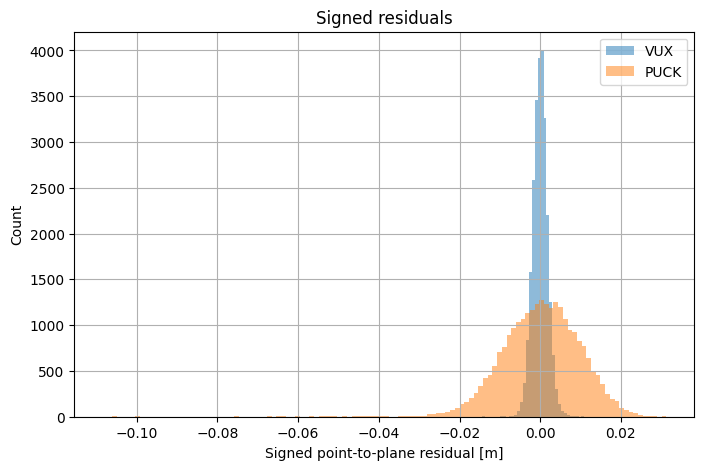

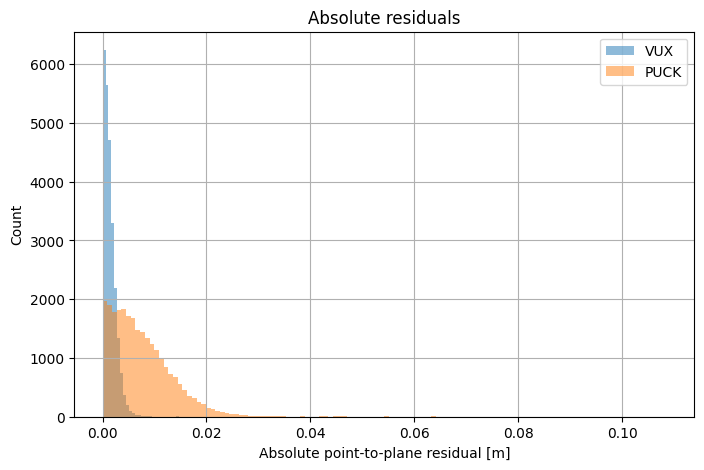

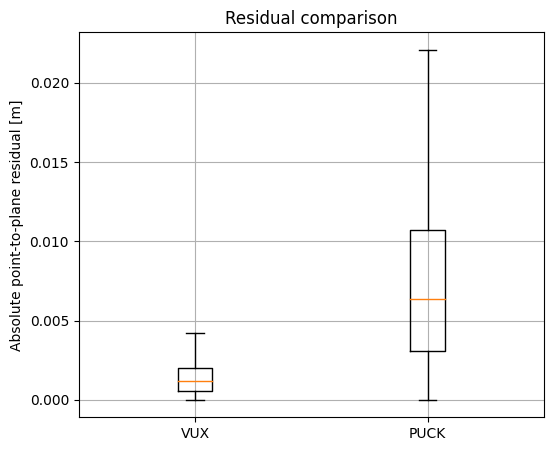

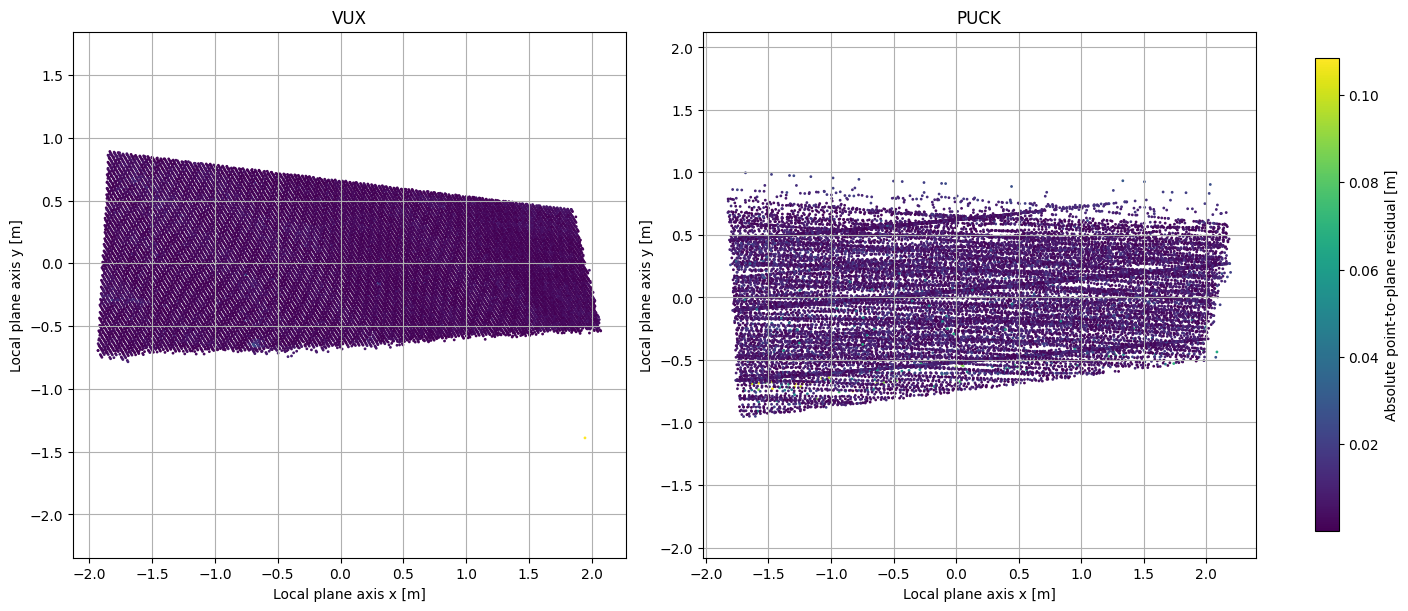

In [52]:
from pathlib import Path
import numpy as np
import pandas as pd
import laspy
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
cloud_1 = Path("/media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/wall3/wall_crop_VUX.las")
cloud_2 = Path("/media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/wall3/wall_crop_PUCK.las")

label_1 = "VUX"
label_2 = "PUCK"

output_dir = "/home/b085164/PDM_Romain_Defferrard/images/noise_puck"

max_plot_points = 200000  # subsampling for plotting


# ============================================================
# HELPERS
# ============================================================
def load_xyz(las_path: Path) -> np.ndarray:
    las = laspy.read(las_path)
    xyz = np.column_stack((las.x, las.y, las.z)).astype(np.float64)
    return xyz

def fit_plane_svd(xyz: np.ndarray):
    """
    Fit plane by SVD.
    Returns centroid and unit normal.
    """
    centroid = xyz.mean(axis=0)
    X = xyz - centroid
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    normal = vt[-1]
    normal = normal / np.linalg.norm(normal)
    return centroid, normal

def point_to_plane_signed_distance(xyz: np.ndarray, centroid: np.ndarray, normal: np.ndarray) -> np.ndarray:
    return (xyz - centroid) @ normal

def make_local_plane_coords(xyz: np.ndarray, centroid: np.ndarray, normal: np.ndarray):
    """
    Build 2D local coordinates on the plane for visualization.
    """
    ref = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(ref, normal)) > 0.9:
        ref = np.array([0.0, 1.0, 0.0])

    u = np.cross(normal, ref)
    u = u / np.linalg.norm(u)

    v = np.cross(normal, u)
    v = v / np.linalg.norm(v)

    dxyz = xyz - centroid
    xu = dxyz @ u
    xv = dxyz @ v
    return xu, xv

def analyze_cloud(xyz: np.ndarray, label: str):
    centroid, normal = fit_plane_svd(xyz)
    d_signed = point_to_plane_signed_distance(xyz, centroid, normal)
    d_abs = np.abs(d_signed)

    stats = {
        "label": label,
        "n_points": len(xyz),
        "mean_signed_m": float(np.mean(d_signed)),
        "std_signed_m": float(np.std(d_signed)),
        "rmse_m": float(np.sqrt(np.mean(d_signed**2))),
        "mean_abs_m": float(np.mean(d_abs)),
        "p50_abs_m": float(np.percentile(d_abs, 50)),
        "p90_abs_m": float(np.percentile(d_abs, 90)),
        "p95_abs_m": float(np.percentile(d_abs, 95)),
        "p99_abs_m": float(np.percentile(d_abs, 99)),
        "max_abs_m": float(np.max(d_abs)),
    }

    return {
        "label": label,
        "xyz": xyz,
        "centroid": centroid,
        "normal": normal,
        "d_signed": d_signed,
        "d_abs": d_abs,
        "stats": stats,
    }


# ============================================================
# LOAD
# ============================================================
xyz1 = load_xyz(cloud_1)
xyz2 = load_xyz(cloud_2)

print(f"{label_1}: {len(xyz1)} points")
print(f"{label_2}: {len(xyz2)} points")

# ============================================================
# ANALYZE
# ============================================================
res1 = analyze_cloud(xyz1, label_1)
res2 = analyze_cloud(xyz2, label_2)

# ============================================================
# STATS TABLE
# ============================================================
df_stats = pd.DataFrame([res1["stats"], res2["stats"]])
display(df_stats)

# ============================================================
# HISTOGRAM — SIGNED RESIDUALS
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(res1["d_signed"], bins=120, alpha=0.5, label=label_1)
plt.hist(res2["d_signed"], bins=120, alpha=0.5, label=label_2)
plt.xlabel("Signed point-to-plane residual [m]")
plt.ylabel("Count")
plt.title("Signed residuals")
plt.grid(True)
plt.legend()
plt.savefig(f"{output_dir}/signed_residuals.png", dpi=400)
plt.show()

# ============================================================
# HISTOGRAM — ABSOLUTE RESIDUALS
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(res1["d_abs"], bins=120, alpha=0.5, label=label_1)
plt.hist(res2["d_abs"], bins=120, alpha=0.5, label=label_2)
plt.xlabel("Absolute point-to-plane residual [m]")
plt.ylabel("Count")
plt.title("Absolute residuals")
plt.grid(True)
plt.legend()
plt.savefig(f"{output_dir}/absolute_residuals.png", dpi=400)
plt.show()

# ============================================================
# BOXPLOT — ABSOLUTE RESIDUALS
# ============================================================
plt.figure(figsize=(6, 5))
plt.boxplot([res1["d_abs"], res2["d_abs"]], labels=[label_1, label_2], showfliers=False)
plt.ylabel("Absolute point-to-plane residual [m]")
plt.title("Residual comparison")
plt.grid(True)
plt.savefig(f"{output_dir}/residuals_boxplot.png", dpi=400)
plt.show()

# ============================================================
# SPATIAL RESIDUAL MAPS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, res in zip(axes, [res1, res2]):
    xu, xv = make_local_plane_coords(res["xyz"], res["centroid"], res["normal"])

    n = len(xu)
    if n > max_plot_points:
        idx = np.random.choice(n, max_plot_points, replace=False)
    else:
        idx = np.arange(n)

    sc = ax.scatter(
        xv[idx],
        xu[idx],
        c=res["d_abs"][idx],
        s=1,
    )
    ax.set_title(res["label"])
    ax.set_xlabel("Local plane axis x [m]")
    ax.set_ylabel("Local plane axis y [m]")
    ax.axis("equal")
    ax.grid(True)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("Absolute point-to-plane residual [m]")
plt.savefig(f"{output_dir}/spatial_residuals.png", dpi=400)
plt.show()

## Lampadaire

In [42]:
from pathlib import Path
import numpy as np
import laspy

# ============================================================
# INPUT / OUTPUT
# ============================================================
input_cloud = Path("/media/b085164/Elements/CALIB_26_02_25/georef_VUX_traj_ODyN/merged/HA_LR/merged_1000_HA_LR.las")
output_cloud = Path("/media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/pole/pole_VUX.las")

# ============================================================
# XY BOX (au sol)
# ============================================================
xmin = 2542373.25
xmax = 2542376.5
ymin = 1157072
ymax = 1157075

# ============================================================
# Z RANGE
# ============================================================
z_min = 897.5
z_max = 906.0

# ============================================================
# STREAMING PARAMS
# ============================================================
chunk_size = 2_000_000

# ============================================================
# RUN
# ============================================================
n_written = 0

with laspy.open(input_cloud) as reader:
    header = reader.header

    output_cloud.parent.mkdir(parents=True, exist_ok=True)

    with laspy.open(output_cloud, mode="w", header=header) as writer:
        for pts in reader.chunk_iterator(chunk_size):
            x = np.asarray(pts.x)
            y = np.asarray(pts.y)
            z = np.asarray(pts.z)

            mask_xy = (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)
            mask_z = (z >= z_min) & (z <= z_max)
            mask = mask_xy & mask_z

            if np.any(mask):
                writer.write_points(pts[mask])
                n_written += int(mask.sum())

print(f"Saved: {output_cloud}")
print(f"Points written: {n_written}")
print(f"Crop box: x=[{xmin}, {xmax}], y=[{ymin}, {ymax}], z=[{z_min}, {z_max}]")

Saved: /media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/pole/pole_VUX.las
Points written: 5738
Crop box: x=[2542373.25, 2542376.5], y=[1157072, 1157075], z=[897.5, 906.0]


VUX  points: 5738
PUCK points: 2139


,z0,z1,z_center,xc_ref,yc_ref,r_ref,n_vux_raw,n_vux_kept,vux_slice_rmse,vux_slice_p95
0,897.5,897.7,897.6,2542375.002,1157074.784,0.080864,236,236,0.049288,0.086869
1,897.7,897.9,897.8,2542375.003,1157074.781,0.077801,237,237,0.047264,0.083062
2,897.9,898.1,898.0,2542375.005,1157074.778,0.078390,233,233,0.045606,0.078636
3,898.1,898.3,898.2,2542375.006,1157074.778,0.075422,226,226,0.045432,0.079357
4,898.3,898.5,898.4,2542375.005,1157074.779,0.075027,223,223,0.045158,0.079460


,label,n_input,n_kept,n_slices,keep_ratio,mean_abs_radial_residual_m,std_radial_residual_m,rmse_radial_residual_m,p50_abs_radial_residual_m,p90_abs_radial_residual_m,p95_abs_radial_residual_m,p99_abs_radial_residual_m,max_abs_radial_residual_m
0,VUX reference,5738,5716,42,0.996166,0.030622,0.036690,0.036826,0.028047,0.058750,0.066630,0.083661,0.107733
1,PUCK vs VUX reference,2139,1976,24,0.923796,0.037580,0.045157,0.045571,0.034264,0.070315,0.086136,0.118453,0.169015


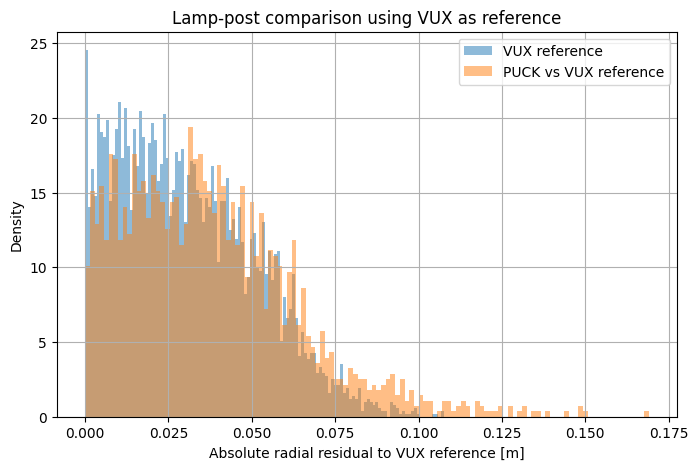

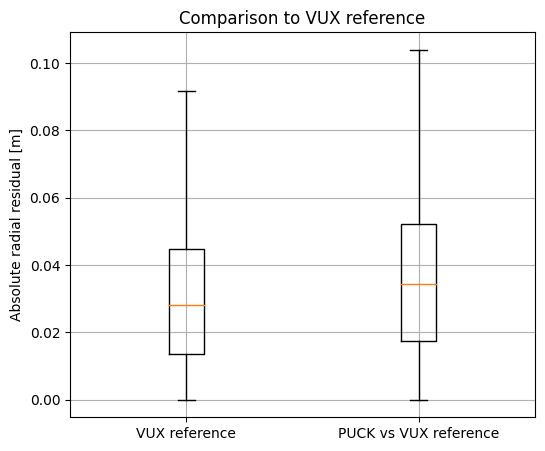

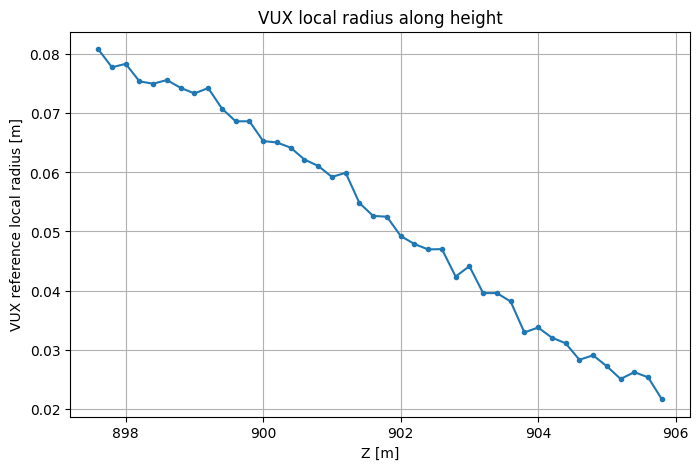

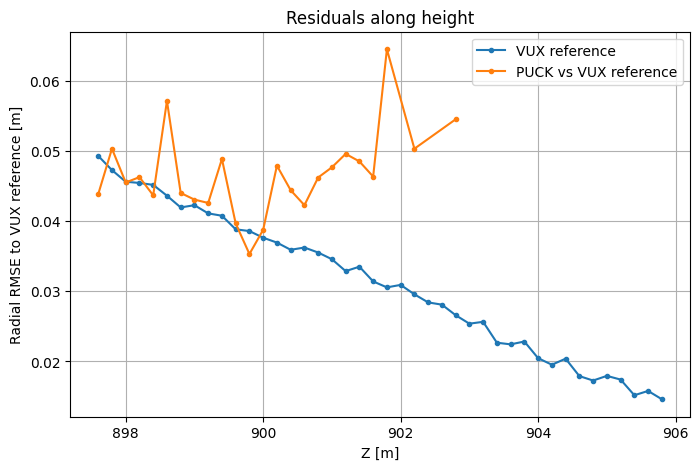

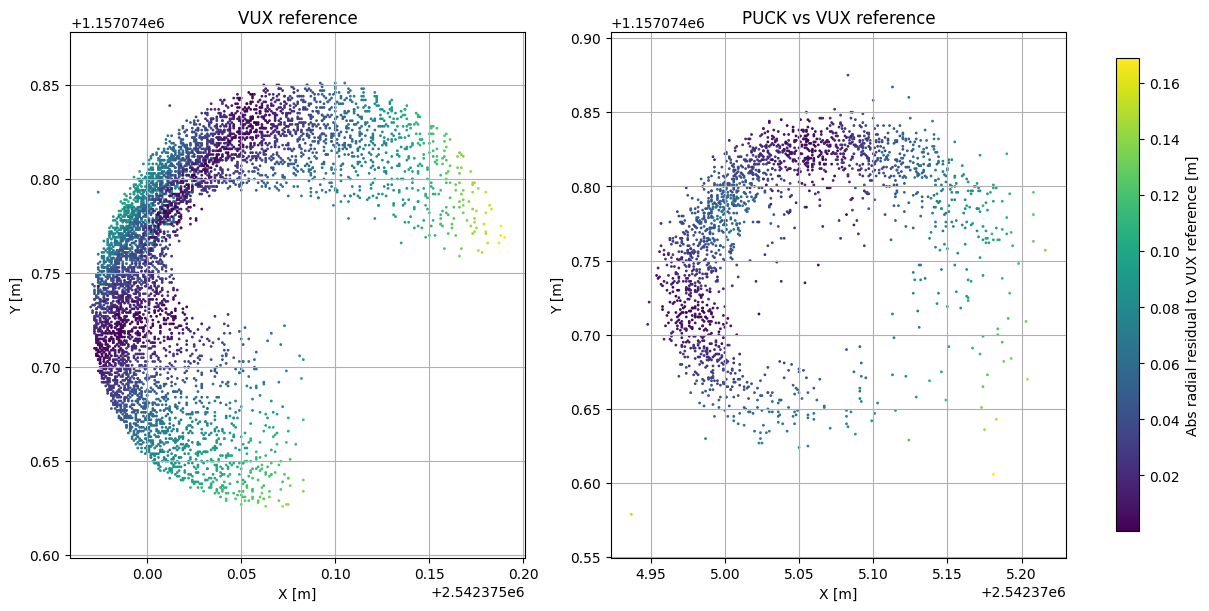

In [50]:
from pathlib import Path
import numpy as np
import pandas as pd
import laspy
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
cloud_vux = Path("/media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/pole/pole_VUX.las")
cloud_puck = Path("/media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK/pole/pole_PUCK.las")

label_ref = "VUX reference"
label_cmp = "PUCK vs VUX reference"

z_bin = 0.2              # épaisseur des tranches [m]
min_pts_vux = 20          # min points VUX par tranche
min_pts_puck = 20         # min points PUCK par tranche
mad_thresh_vux = 3.5      # filtre robuste sur VUX
mad_thresh_puck = 4.0     # filtre robuste sur PUCK
max_plot_points = 200000


# ============================================================
# HELPERS
# ============================================================
def load_xyz(las_path: Path) -> np.ndarray:
    las = laspy.read(las_path)
    return np.column_stack((las.x, las.y, las.z)).astype(np.float64)

def mad_stats(x: np.ndarray):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    sigma = 1.4826 * mad
    return med, mad, sigma

def subsample(arr: np.ndarray, n_max: int):
    if len(arr) <= n_max:
        return arr
    idx = np.random.choice(len(arr), n_max, replace=False)
    return arr[idx]

def extract_reference_slices_from_vux(xyz_vux: np.ndarray, z_bin: float, min_pts_vux: int, mad_thresh_vux: float):
    """
    Build slice-wise reference geometry from VUX:
      - z_center
      - xc_ref, yc_ref
      - r_ref (local median radius)
    using robust filtering within each slice.
    """
    z = xyz_vux[:, 2]
    zmin, zmax = z.min(), z.max()
    edges = np.arange(zmin, zmax + z_bin, z_bin)

    rows = []

    for i in range(len(edges) - 1):
        z0, z1 = edges[i], edges[i + 1]
        mask = (z >= z0) & (z < z1)
        if mask.sum() < min_pts_vux:
            continue

        pts = xyz_vux[mask]
        x = pts[:, 0]
        y = pts[:, 1]

        # centre robuste initial
        xc0 = np.median(x)
        yc0 = np.median(y)

        r0 = np.sqrt((x - xc0)**2 + (y - yc0)**2)
        r_med0, _, r_sig0 = mad_stats(r0)

        if r_sig0 == 0:
            keep = np.ones_like(r0, dtype=bool)
        else:
            keep = np.abs(r0 - r_med0) <= mad_thresh_vux * r_sig0

        pts_in = pts[keep]
        if len(pts_in) < min_pts_vux:
            continue

        x_in = pts_in[:, 0]
        y_in = pts_in[:, 1]

        # centre robuste final
        xc = np.median(x_in)
        yc = np.median(y_in)

        r = np.sqrt((x_in - xc)**2 + (y_in - yc)**2)
        r_ref = np.median(r)

        rows.append({
            "z0": float(z0),
            "z1": float(z1),
            "z_center": float(0.5 * (z0 + z1)),
            "xc_ref": float(xc),
            "yc_ref": float(yc),
            "r_ref": float(r_ref),
            "n_vux_raw": int(len(pts)),
            "n_vux_kept": int(len(pts_in)),
            "vux_slice_rmse": float(np.sqrt(np.mean((r - r_ref)**2))),
            "vux_slice_p95": float(np.percentile(np.abs(r - r_ref), 95)),
        })

    if len(rows) == 0:
        raise ValueError("No valid VUX slices found.")

    return pd.DataFrame(rows)

def compare_cloud_to_vux_reference(xyz: np.ndarray, df_ref: pd.DataFrame, label: str,
                                   min_pts_cloud: int, mad_thresh_cloud: float):
    """
    Compare a cloud to VUX slice reference:
    for each slice, compute radial residuals relative to (xc_ref, yc_ref, r_ref).
    """
    rows = []
    dr_all = []
    xyz_kept_all = []

    z = xyz[:, 2]

    for _, ref in df_ref.iterrows():
        z0 = ref["z0"]
        z1 = ref["z1"]
        xc = ref["xc_ref"]
        yc = ref["yc_ref"]
        r_ref = ref["r_ref"]

        mask = (z >= z0) & (z < z1)
        if mask.sum() < min_pts_cloud:
            continue

        pts = xyz[mask]
        x = pts[:, 0]
        y = pts[:, 1]

        r = np.sqrt((x - xc)**2 + (y - yc)**2)

        # résidu radial par rapport au rayon VUX
        dr0 = r - r_ref

        # rejet robuste des outliers très éloignés
        med0, _, sig0 = mad_stats(dr0)
        if sig0 == 0:
            keep = np.ones_like(dr0, dtype=bool)
        else:
            keep = np.abs(dr0 - med0) <= mad_thresh_cloud * sig0

        pts_in = pts[keep]
        dr_in = dr0[keep]

        if len(pts_in) < min_pts_cloud:
            continue

        dr_all.append(dr_in)
        xyz_kept_all.append(pts_in)

        rows.append({
            "z_center": float(ref["z_center"]),
            "n_raw": int(len(pts)),
            "n_kept": int(len(pts_in)),
            "r_ref": float(r_ref),
            "rmse_dr": float(np.sqrt(np.mean(dr_in**2))),
            "p95_abs_dr": float(np.percentile(np.abs(dr_in), 95)),
        })

    if len(rows) == 0:
        raise ValueError(f"No valid comparison slices found for {label}")

    dr_all = np.concatenate(dr_all)
    xyz_kept_all = np.vstack(xyz_kept_all)
    df_slices = pd.DataFrame(rows)

    stats = {
        "label": label,
        "n_input": len(xyz),
        "n_kept": len(xyz_kept_all),
        "n_slices": len(df_slices),
        "keep_ratio": len(xyz_kept_all) / len(xyz),
        "mean_abs_radial_residual_m": float(np.mean(np.abs(dr_all))),
        "std_radial_residual_m": float(np.std(dr_all)),
        "rmse_radial_residual_m": float(np.sqrt(np.mean(dr_all**2))),
        "p50_abs_radial_residual_m": float(np.percentile(np.abs(dr_all), 50)),
        "p90_abs_radial_residual_m": float(np.percentile(np.abs(dr_all), 90)),
        "p95_abs_radial_residual_m": float(np.percentile(np.abs(dr_all), 95)),
        "p99_abs_radial_residual_m": float(np.percentile(np.abs(dr_all), 99)),
        "max_abs_radial_residual_m": float(np.max(np.abs(dr_all))),
    }

    return {
        "label": label,
        "xyz_kept": xyz_kept_all,
        "dr_all": dr_all,
        "df_slices": df_slices,
        "stats": stats,
    }


# ============================================================
# LOAD
# ============================================================
xyz_vux = load_xyz(cloud_vux)
xyz_puck = load_xyz(cloud_puck)

print(f"VUX  points: {len(xyz_vux)}")
print(f"PUCK points: {len(xyz_puck)}")

# ============================================================
# BUILD VUX REFERENCE BY SLICES
# ============================================================
df_ref = extract_reference_slices_from_vux(
    xyz_vux=xyz_vux,
    z_bin=z_bin,
    min_pts_vux=min_pts_vux,
    mad_thresh_vux=mad_thresh_vux,
)

display(df_ref.head())

# ============================================================
# COMPARE BOTH CLOUDS TO SAME VUX REFERENCE
# ============================================================
res_vux = compare_cloud_to_vux_reference(
    xyz=xyz_vux,
    df_ref=df_ref,
    label=label_ref,
    min_pts_cloud=min_pts_vux,
    mad_thresh_cloud=mad_thresh_vux,
)

res_puck = compare_cloud_to_vux_reference(
    xyz=xyz_puck,
    df_ref=df_ref,
    label=label_cmp,
    min_pts_cloud=min_pts_puck,
    mad_thresh_cloud=mad_thresh_puck,
)

# ============================================================
# STATS TABLE
# ============================================================
df_stats = pd.DataFrame([res_vux["stats"], res_puck["stats"]])
display(df_stats)

# ============================================================
# HISTOGRAM (normalized)
# ============================================================
dr_vux = np.abs(res_vux["dr_all"])
dr_puck = np.abs(res_puck["dr_all"])

dr_vux_plot = subsample(dr_vux, max_plot_points)
dr_puck_plot = subsample(dr_puck, max_plot_points)

plt.figure(figsize=(8, 5))
plt.hist(dr_vux_plot, bins=120, density=True, alpha=0.5, label=label_ref)
plt.hist(dr_puck_plot, bins=120, density=True, alpha=0.5, label=label_cmp)
plt.xlabel("Absolute radial residual to VUX reference [m]")
plt.ylabel("Density")
plt.title("Lamp-post comparison using VUX as reference")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# BOXPLOT
# ============================================================
plt.figure(figsize=(6, 5))
plt.boxplot([dr_vux_plot, dr_puck_plot], labels=[label_ref, label_cmp], showfliers=False)
plt.ylabel("Absolute radial residual [m]")
plt.title("Comparison to VUX reference")
plt.grid(True)
plt.show()

# ============================================================
# RADIUS OF VUX REFERENCE ALONG HEIGHT
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(df_ref["z_center"], df_ref["r_ref"], ".-")
plt.xlabel("Z [m]")
plt.ylabel("VUX reference local radius [m]")
plt.title("VUX local radius along height")
plt.grid(True)
plt.show()

# ============================================================
# NOISE VS HEIGHT
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(res_vux["df_slices"]["z_center"], res_vux["df_slices"]["rmse_dr"], ".-", label=label_ref)
plt.plot(res_puck["df_slices"]["z_center"], res_puck["df_slices"]["rmse_dr"], ".-", label=label_cmp)
plt.xlabel("Z [m]")
plt.ylabel("Radial RMSE to VUX reference [m]")
plt.title("Residuals along height")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# XY VIEW OF KEPT POINTS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for ax, xyzk, dr, title in [
    (axes[0], res_vux["xyz_kept"], np.abs(res_vux["dr_all"]), label_ref),
    (axes[1], res_puck["xyz_kept"], np.abs(res_puck["dr_all"]), label_cmp),
]:
    if len(xyzk) > max_plot_points:
        idx = np.random.choice(len(xyzk), max_plot_points, replace=False)
    else:
        idx = np.arange(len(xyzk))

    sc = ax.scatter(
        xyzk[idx, 0],
        xyzk[idx, 1],
        c=np.abs(dr[idx]),
        s=1,
    )
    ax.set_title(title)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.axis("equal")
    ax.grid(True)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("Abs radial residual to VUX reference [m]")

plt.show()